# 01 — Exploratory Data Analysis

Spotify Music Dataset (Kaggle): high + low popularity CSVs concatenated.

Goals:
1. Validate shape, types, missingness.
2. Inspect audio feature distributions and correlations.
3. Examine popularity, genre balance, and per-genre audio profiles.
4. Sanity-check valence/energy mood quadrants.
5. Decide whether PCA buys us anything for clustering.

## 1. Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from src.preprocessing import load_dataset, scale_features, HIGH_POP, LOW_POP
from src.features import AUDIO_FEATURES
from src import eda

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
RNG = 42

## 2. Load & basic shape

In [2]:
high = pd.read_csv(HIGH_POP)
low = pd.read_csv(LOW_POP)
print(f"high_popularity rows: {len(high):,}")
print(f"low_popularity  rows: {len(low):,}")
print(f"shared columns: {len(set(high.columns) & set(low.columns))}/{len(high.columns)}")

high_popularity rows: 1,686
low_popularity  rows: 3,145
shared columns: 29/29


In [3]:
df = load_dataset()
print(f"after concat + dedupe by track_id + drop NA on modeling features: {df.shape}")
df.head()

after concat + dedupe by track_id + drop NA on modeling features: (4494, 29)


,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,track_popularity,track_href,uri,track_album_name,playlist_name,analysis_url,track_id,track_name,track_album_release_date,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,100,https://api.spotify.com/v1/tracks/2plbrEY59Iik...,spotify:track:2plbrEY59IikOBgBGLjaoe,Die With A Smile,Today's Top Hits,https://api.spotify.com/v1/audio-analysis/2plb...,2plbrEY59IikOBgBGLjaoe,Die With A Smile,2024-08-16,0.0000,10FLjwfpbxLmW8c25Xyc2N,0.0,6.0,251668.0,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4.0,0.0358,97,https://api.spotify.com/v1/tracks/6dOtVTDdiauQ...,spotify:track:6dOtVTDdiauQNBQEDOtlAB,HIT ME HARD AND SOFT,Today's Top Hits,https://api.spotify.com/v1/audio-analysis/6dOt...,6dOtVTDdiauQNBQEDOtlAB,BIRDS OF A FEATHER,2024-05-17,0.0608,7aJuG4TFXa2hmE4z1yxc3n,1.0,2.0,210373.0,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4.0,0.0368,93,https://api.spotify.com/v1/tracks/7ne4VBA60CxG...,spotify:track:7ne4VBA60CxGM75vw0EYad,The Secret of Us (Deluxe),Today's Top Hits,https://api.spotify.com/v1/audio-analysis/7ne4...,7ne4VBA60CxGM75vw0EYad,That’s So True,2024-10-18,0.0000,0hBRqPYPXhr1RkTDG3n4Mk,1.0,1.0,166300.0,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4.0,0.0634,81,https://api.spotify.com/v1/tracks/1d7Ptw3qYcfp...,spotify:track:1d7Ptw3qYcfpdLNL5REhtJ,Short n' Sweet,Today's Top Hits,https://api.spotify.com/v1/audio-analysis/1d7P...,1d7Ptw3qYcfpdLNL5REhtJ,Taste,2024-08-23,0.0000,4B4Elma4nNDUyl6D5PvQkj,0.0,0.0,157280.0,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,98,https://api.spotify.com/v1/tracks/5vNRhkKd0yEA...,spotify:track:5vNRhkKd0yEAg8suGBpjeY,APT.,Today's Top Hits,https://api.spotify.com/v1/audio-analysis/5vNR...,5vNRhkKd0yEAg8suGBpjeY,APT.,2024-10-18,0.0000,2IYQwwgxgOIn7t3iF6ufFD,0.0,0.0,169917.0,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M


In [4]:
df.isna().sum().sort_values(ascending=False).head(10)

track_album_name    1
tempo               0
danceability        0
playlist_genre      0
energy              0
liveness            0
valence             0
track_artist        0
time_signature      0
speechiness         0
dtype: int64

In [5]:
df[AUDIO_FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
danceability,4494.0,0.620488,0.189464,0.058900,0.52200,0.653000,0.75700,0.979
energy,4494.0,0.579485,0.249922,0.000202,0.42400,0.627000,0.77300,0.998
valence,4494.0,0.478801,0.259645,0.029600,0.26700,0.480000,0.68875,0.987
acousticness,4494.0,0.351175,0.328892,0.000004,0.05660,0.237500,0.61475,0.996
instrumentalness,4494.0,0.212179,0.359127,0.000000,0.00000,0.000115,0.29975,0.991
speechiness,4494.0,0.100418,0.100533,0.021900,0.03840,0.055000,0.11500,0.927
tempo,4494.0,118.275199,28.705919,48.232000,96.02925,118.081500,137.08475,241.426
loudness,4494.0,-9.487413,7.287315,-48.069000,-10.60650,-7.301000,-5.39050,1.318


## 3. Audio feature distributions

Look for skew (instrumentalness, speechiness usually heavy-tailed) and obvious bimodality (loudness, tempo).

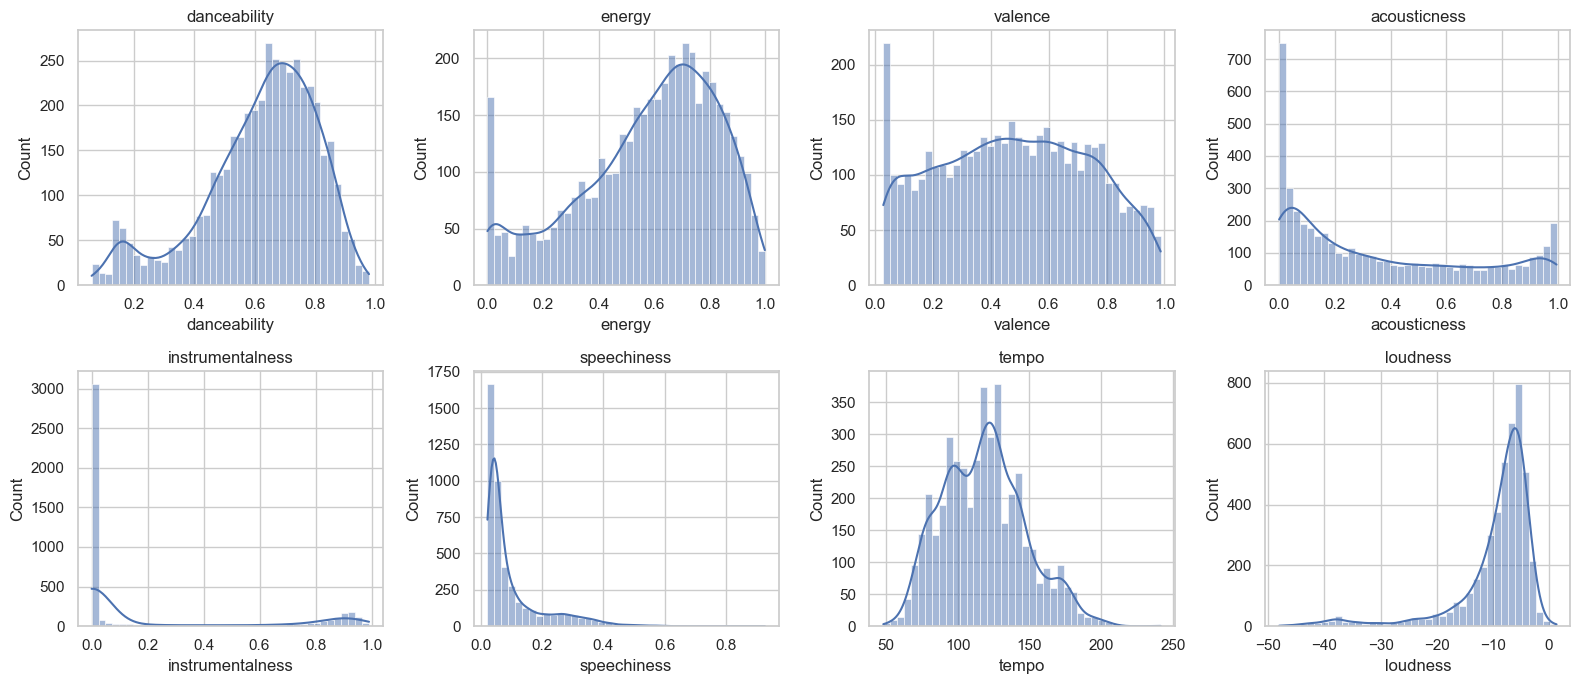

In [6]:
fig = eda.feature_distributions(df)
plt.show()

## 4. Correlation heatmap

Strong correlations (e.g. energy ↔ loudness, energy ↔ acousticness) hint at redundancy worth noting when interpreting clusters.

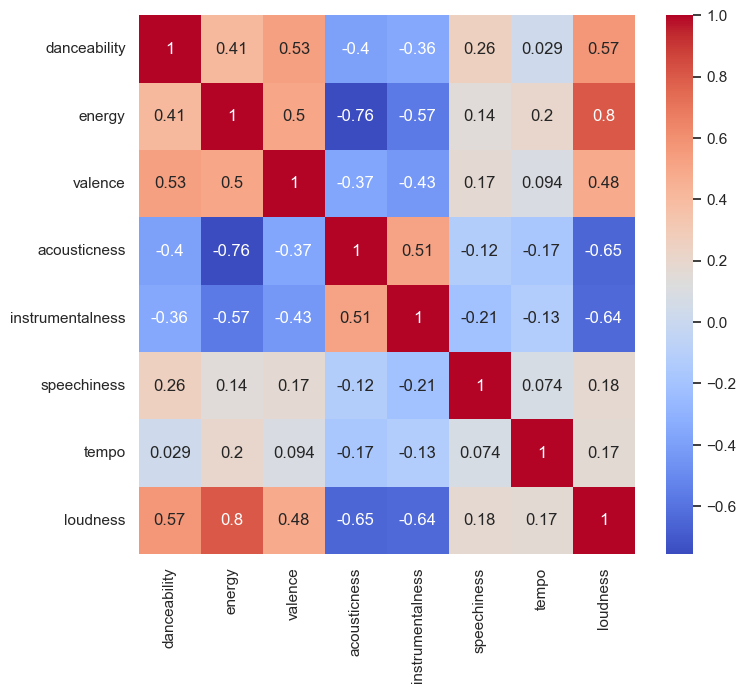

In [7]:
fig = eda.correlation_heatmap(df)
plt.show()

## 5. Popularity distribution

The dataset was assembled from two pools (high/low). Confirm they actually separate, and inspect overall popularity skew — feeds the hidden-gems threshold.

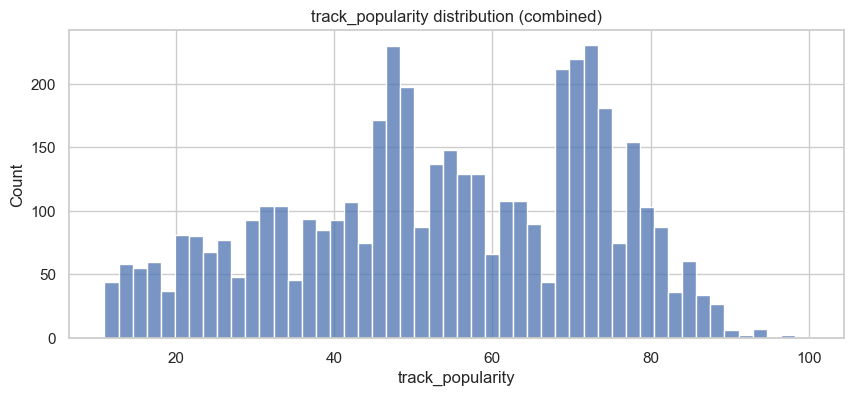

count    4494.000000
mean       53.289275
std        19.557376
min        11.000000
25%        39.000000
50%        54.000000
75%        70.000000
max       100.000000
Name: track_popularity, dtype: float64

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df["track_popularity"], bins=50, ax=ax)
ax.set_title("track_popularity distribution (combined)")
plt.show()
df["track_popularity"].describe()

In [ ]:
high_tagged = high.assign(source="high_popularity")
low_tagged = low.assign(source="low_popularity")
tagged = pd.concat([high_tagged, low_tagged], ignore_index=True)
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(data=tagged, x="track_popularity", hue="source", bins=50,
             element="step", stat="count", common_norm=False, ax=ax)
ax.set_title("track_popularity by source file")
plt.show()

## 6. Genre balance

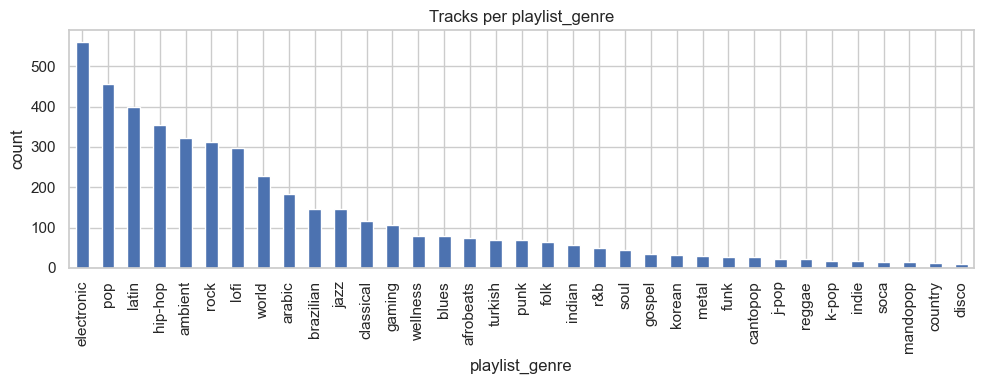

playlist_genre
electronic    561
pop           456
latin         400
hip-hop       355
ambient       321
rock          312
lofi          298
world         228
arabic        184
brazilian     147
jazz          145
classical     116
gaming        107
wellness       80
blues          79
afrobeats      73
turkish        70
punk           70
folk           64
indian         56
r&b            50
soul           44
gospel         34
korean         32
metal          30
funk           28
cantopop       27
j-pop          23
reggae         23
k-pop          17
indie          16
soca           14
mandopop       14
country        11
disco           9
Name: count, dtype: int64

In [9]:
genre_counts = df["playlist_genre"].value_counts()
fig, ax = plt.subplots(figsize=(10, 4))
genre_counts.plot.bar(ax=ax)
ax.set_title("Tracks per playlist_genre")
ax.set_ylabel("count")
plt.tight_layout(); plt.show()
genre_counts

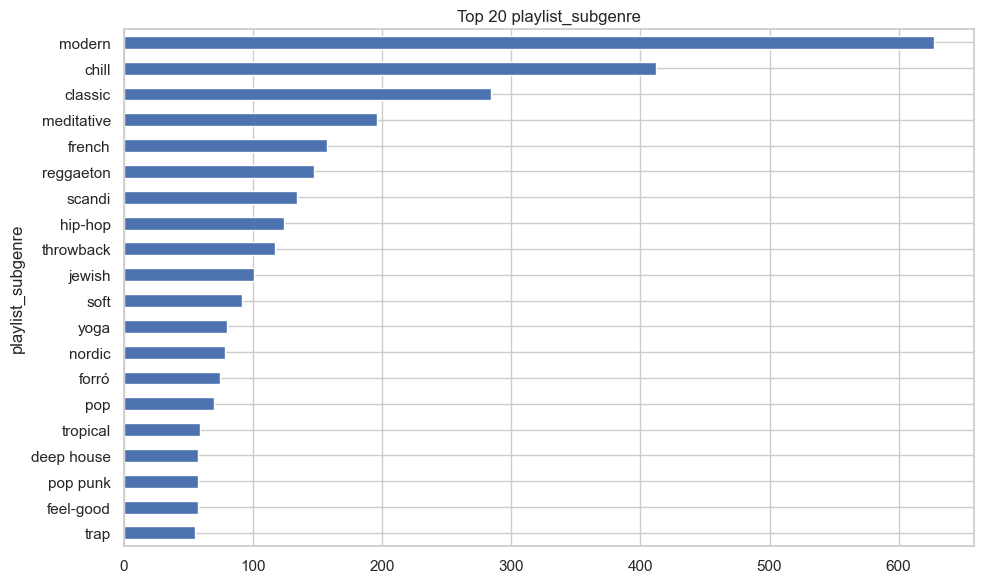

In [10]:
sub = df["playlist_subgenre"].value_counts().head(20)
fig, ax = plt.subplots(figsize=(10, 6))
sub.plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_title("Top 20 playlist_subgenre")
plt.tight_layout(); plt.show()

## 7. Audio profile by genre

Mean MinMax-scaled features per genre. This table is the key reference when assigning archetype labels to K-means clusters.

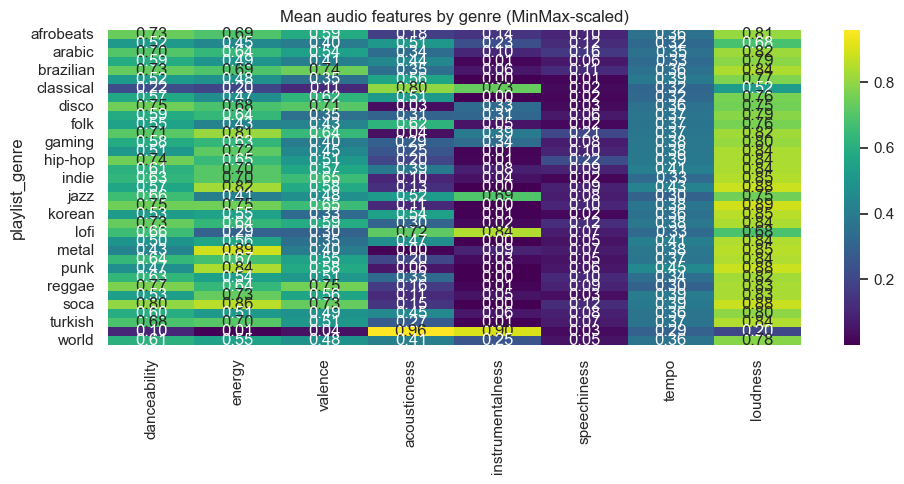

,danceability,energy,valence,acousticness,instrumentalness,speechiness,tempo,loudness
playlist_genre,,,,,,,,
afrobeats,0.734514,0.688671,0.585278,0.179446,0.143323,0.097389,0.359354,0.806180
ambient,0.517084,0.445841,0.399924,0.508814,0.229184,0.119581,0.323791,0.677707
arabic,0.697428,0.637441,0.539774,0.336874,0.102322,0.155350,0.354745,0.817821
blues,0.588240,0.494066,0.409707,0.442098,0.013620,0.061217,0.328825,0.789416
brazilian,0.726523,0.689043,0.743836,0.345100,0.057153,0.113585,0.361821,0.840013
cantopop,0.520221,0.479372,0.347887,0.560210,0.000349,0.014715,0.385599,0.773910
classical,0.216959,0.197663,0.111531,0.797030,0.732489,0.023402,0.317377,0.520672
country,0.573268,0.466279,0.621323,0.513050,0.000244,0.018059,0.317997,0.759353
disco,0.746767,0.681632,0.705220,0.030462,0.329067,0.025755,0.357291,0.753142


In [11]:
scaled, _ = scale_features(df)
profile = scaled.groupby("playlist_genre")[AUDIO_FEATURES].mean().sort_index()
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(profile, annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Mean audio features by genre (MinMax-scaled)")
plt.tight_layout(); plt.show()
profile

## 8. Mood space (valence × energy)

Quadrant lines at 0.5 mirror the rule-based mood classifier in `src/mood.py`. If a quadrant is sparsely populated, the rule may need tuning.

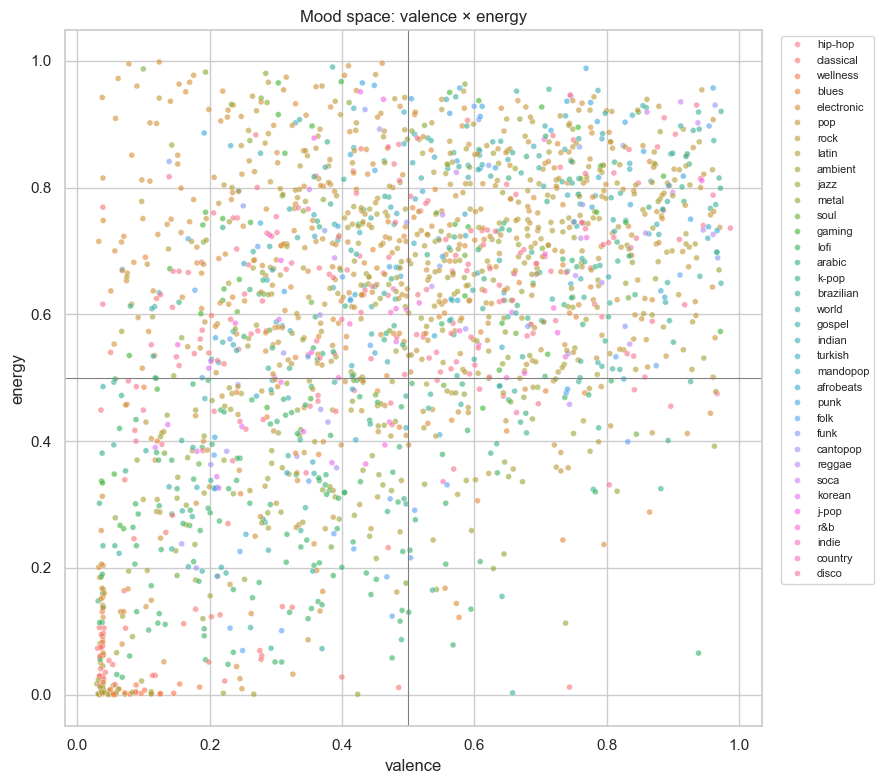

In [12]:
sample = df.sample(min(2000, len(df)), random_state=RNG)
fig, ax = plt.subplots(figsize=(9, 8))
sns.scatterplot(data=sample, x="valence", y="energy", hue="playlist_genre",
                alpha=0.6, s=18, ax=ax)
ax.axhline(0.5, color="gray", lw=0.8)
ax.axvline(0.5, color="gray", lw=0.8)
ax.set_title("Mood space: valence \u00d7 energy")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

## 9. PCA — does dimensionality reduction help?

Per the feedback, PCA stays in EDA/visualization, not the recommender. Useful here to (a) spot clusters by genre in 2D, (b) check whether 8 features carry redundant variance.

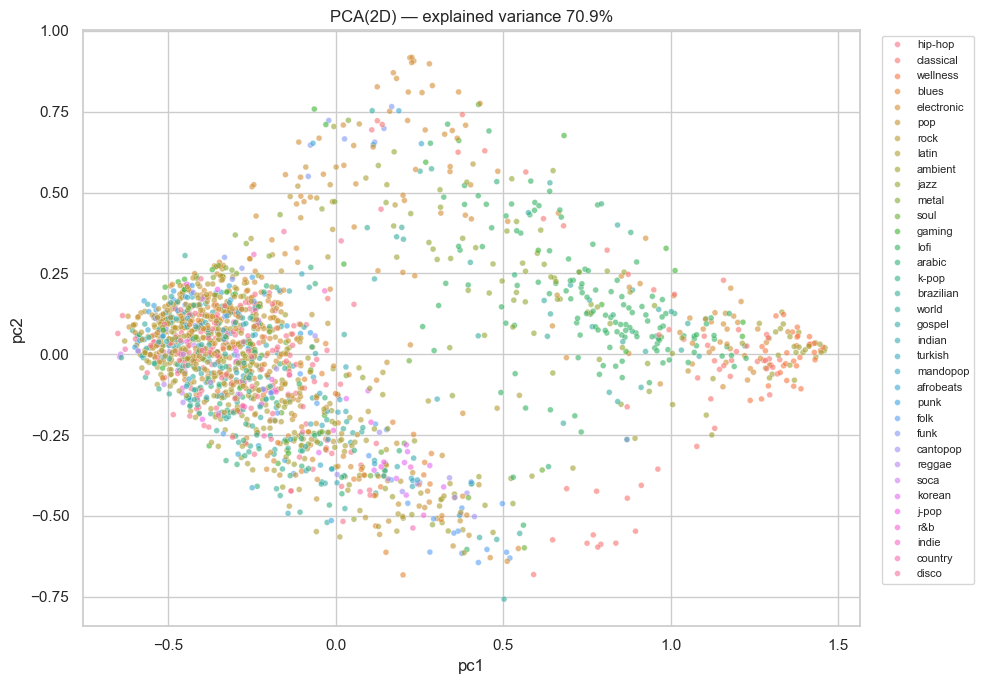

In [13]:
pca = PCA(n_components=2, random_state=RNG)
coords = pca.fit_transform(scaled[AUDIO_FEATURES].values)
plot_df = pd.DataFrame(coords, columns=["pc1", "pc2"])
plot_df["genre"] = scaled["playlist_genre"].values

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=plot_df.sample(min(2000, len(plot_df)), random_state=RNG),
                x="pc1", y="pc2", hue="genre", alpha=0.6, s=18, ax=ax)
ax.set_title(f"PCA(2D) \u2014 explained variance {pca.explained_variance_ratio_.sum():.1%}")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

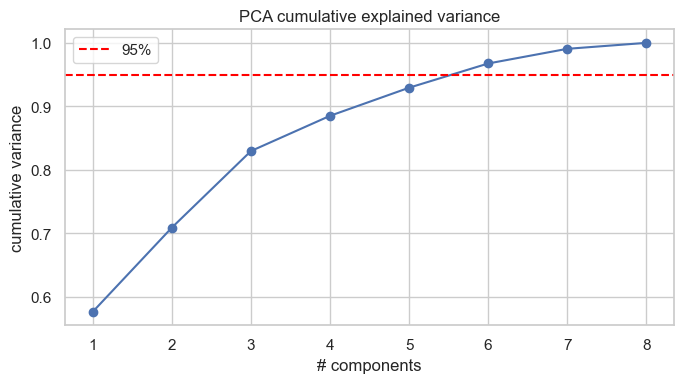

per-component variance: [0.577 0.132 0.121 0.055 0.044 0.038 0.023 0.009]


In [14]:
pca_full = PCA(random_state=RNG).fit(scaled[AUDIO_FEATURES].values)
cum = np.cumsum(pca_full.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(cum) + 1), cum, marker="o")
ax.axhline(0.95, color="red", ls="--", label="95%")
ax.set_xlabel("# components"); ax.set_ylabel("cumulative variance")
ax.set_title("PCA cumulative explained variance")
ax.legend(); plt.tight_layout(); plt.show()
print("per-component variance:", np.round(pca_full.explained_variance_ratio_, 3))

## EDA Summary

- **Distributions:** The final cleaned dataset contains **4,494 tracks and 29 columns** after concatenation, duplicate removal by `track_id`, and dropping rows with missing modeling features. The modeling features have no missing values. Most audio features show usable variation, but several are skewed. `instrumentalness` is highly right-skewed, with most tracks near 0 and a smaller group near high instrumentalness. `speechiness` is also strongly right-skewed, meaning most songs have low speechiness while a few tracks contain much more spoken-word content. `acousticness` is spread widely but has many tracks near 0, suggesting many songs are non-acoustic, with a separate group of highly acoustic tracks. `loudness` has a long low-end tail, with some very quiet outliers. `tempo` is centered around roughly 118 BPM with some high-tempo outliers. `danceability`, `energy`, and `valence` are more evenly distributed, although energy is slightly concentrated above the midpoint.

- **Correlations:** The strongest correlation is between **energy and loudness** at about **0.80**, which makes sense because energetic songs are often louder. There is also a strong negative correlation between **acousticness and energy** at about **-0.76**, showing that highly acoustic songs tend to be less energetic. Other notable relationships include **acousticness and loudness** around **-0.65**, **instrumentalness and loudness** around **-0.64**, and **energy and instrumentalness** around **-0.57**. These correlations suggest some redundancy, especially between energy/loudness and acousticness/instrumentalness. Because of this, PCA is useful for visualization and checking feature redundancy, but the recommendation model should still use the original normalized features for interpretability.

- **Popularity:** The combined `track_popularity` distribution ranges roughly from low popularity values near 10 up to highly popular tracks near 100. The distribution is not cleanly separated into two perfectly distinct groups; instead, it appears somewhat mixed with heavier concentrations around the mid-popularity and higher-popularity ranges. For the hidden-gems feature, a reasonable cutoff is to define hidden gems as tracks with high similarity to the user profile but with popularity below the dataset median or below the average popularity of the user's selected songs. Visually, the median appears to be in the mid-to-high 50s, but the exact cutoff should be computed with `df["track_popularity"].median()`.

- **Genres:** The dataset is genre-skewed. The dominant genres are **electronic**, **pop**, **latin**, **hip-hop**, **ambient**, **rock**, and **lofi**. Electronic has the largest count with 561 tracks, followed by pop with 456, latin with 400, hip-hop with 355, ambient with 321, rock with 312, and lofi with 298. Several genres are sparse, including genres such as **disco**, **country**, **mandopop**, and **soca**, which have very small sample sizes. These sparse genres may be too limited for reliable per-genre evaluation, so they should either be grouped into an "Other" category or excluded from genre-specific evaluation metrics.

- **Genre profile heatmap:** The genre profile heatmap shows clear differences in average audio features by genre. Genres such as **wellness**, **classical**, and **lofi** have high acousticness and instrumentalness with lower energy and loudness, making them good candidates for calm or study-related archetypes. Genres such as **soca**, **k-pop**, **funk**, **afrobeats**, **latin**, **reggae**, **brazilian**, and **disco** show higher danceability, energy, valence, and loudness, which fits a dance or upbeat personality label. Genres such as **metal**, **punk**, **rock**, and **j-pop** show high energy and loudness, making them suitable for a high-intensity archetype. Hip-hop stands out with high danceability and relatively high speechiness, which supports a rhythm/flow-based archetype. These patterns can be used to draft the K-means cluster personality labels in the next notebook.

- **Mood quadrants:** The mood space using **valence × energy** shows that all four quadrants are populated. The high-energy/high-valence area is well represented, which supports an upbeat or euphoric mood category. The high-energy/low-valence area is also populated and can represent intense, darker, or driven songs. The low-energy/low-valence area contains many calm, melancholic, or reflective tracks, including very low-energy wellness/classical-style songs. The low-energy/high-valence quadrant exists but is less dense, which fits relaxed or chill-happy music. A simple 0.5 threshold works for visualization, but for final mood labels it may be better to use tuned thresholds such as **0.6 for high valence/energy** and **0.35 for low valence**, so the categories are more distinct.

- **PCA:** The 2D PCA plot explains about **70.9%** of the variance, which is strong enough for visualization. It shows some broad structure in the dataset, especially separation between acoustic/instrumental/low-energy tracks and louder, more energetic tracks. However, genres still overlap heavily, so PCA should not be treated as a perfect genre separator. The cumulative explained variance plot shows that about **6 principal components** are needed to preserve at least **95%** of the variance. Therefore, 2D PCA should be used mainly for visualization, while a 6-component PCA representation can be tested for clustering. For recommendations, the original normalized audio features remain preferable because they are easier to explain to users.